In [1]:
# # This mounts your Google Drive to the Colab VM.
# from google.colab import drive
# drive.mount('/content/drive')

# # TODO: Enter the foldername in your Drive where you have saved the unzipped
# # assignment folder, e.g. 'cs6353/assignments/assignment2/'
# FOLDERNAME = 'assignment2'
# assert FOLDERNAME is not None, "[!] Enter the foldername."

# # Now that we've mounted your Drive, this ensures that
# # the Python interpreter of the Colab VM can load
# # python files from within it.
# import sys
# sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# # This downloads the CIFAR-10 dataset to your Drive
# # if it doesn't already exist.
# %cd /content/drive/My\ Drive/$FOLDERNAME/cs6353/datasets/
# !bash get_datasets.sh
# %cd /content/drive/My\ Drive/$FOLDERNAME

# # Install requirements from colab_requirements.txt
# # TODO: Please change your path below to the colab_requirements.txt file
# ! python -m pip install -r /content/drive/My\ Drive/$FOLDERNAME/colab_requirements.txt

# --------- Laptop ---------
# %cd "/home/jared/Desktop/Fall2025/CS-6353/Homeworks/assignment2/cs6353/datasets/"
# !bash get_datasets.sh
# %cd "/home/jared/Desktop/Fall2025/CS-6353/Homeworks/assignment2"
# --------- Laptop ---------

# --------- Desktop ---------
%cd "/home/jared/CS-6353/Homeworks/assignment2/cs6353/datasets/"
!bash get_datasets.sh
%cd "/home/jared/CS-6353/Homeworks/assignment2/"
# --------- Desktop ---------

# Install requirements from colab_requirements.txt
# TODO: Please change your path below to the colab_requirements.txt file

# --------- Desktop ---------
! python -m pip install -r "/home/jared/CS-6353/Homeworks/assignment2/colab_requirements.txt"
# --------- Desktop ---------

# --------- Laptop ---------
# ! python -m pip install -r "/home/jared/Desktop/Fall2025/CS-6353/Homeworks/assignment2/colab_requirements.txt"
# --------- Laptop ---------

/home/jared/CS-6353/Homeworks/assignment2/cs6353/datasets
--2025-10-01 19:16:37--  http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘cifar-10-python.tar.gz’

cifar-10-python.tar 100%[===================>] 162.60M  17.6MB/s    in 6.5s    

2025-10-01 19:16:44 (24.9 MB/s) - ‘cifar-10-python.tar.gz’ saved [170498071/170498071]

cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1
/home/jared/CS-6353/Homeworks/assignment2


# Softmax exercise

*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](https://utah.instructure.com/courses/919972/assignments/12590082) on the course website.*

This exercise is analogous to the SVM exercise. You will:

- implement a fully-vectorized **loss function** for the Softmax classifier
- implement the fully-vectorized expression for its **analytic gradient**
- **check your implementation** with numerical gradient
- use a validation set to **tune the learning rate and regularization** strength
- **optimize** the loss function with **SGD**
- **visualize** the final learned weights


In [2]:
from __future__ import print_function
import random
import numpy as np
from cs6353.data_utils import load_CIFAR10
import matplotlib.pyplot as plt


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading external modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

In [3]:
def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000, num_dev=500):
    """
    Load the CIFAR-10 dataset from disk and perform preprocessing to prepare
    it for the linear classifier. These are the same steps as we used for the
    SVM, but condensed to a single function.  
    """
    # Load the raw CIFAR-10 data
    cifar10_dir = 'cs6353/datasets/cifar-10-batches-py'
    
    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)
    
    # subsample the data
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]
    mask = np.random.choice(num_training, num_dev, replace=False)
    X_dev = X_train[mask]
    y_dev = y_train[mask]
    
    # Preprocessing: reshape the image data into rows
    X_train = np.reshape(X_train, (X_train.shape[0], -1))
    X_val = np.reshape(X_val, (X_val.shape[0], -1))
    X_test = np.reshape(X_test, (X_test.shape[0], -1))
    X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))
    
    # Normalize the data: subtract the mean image
    mean_image = np.mean(X_train, axis = 0)
    X_train -= mean_image
    X_val -= mean_image
    X_test -= mean_image
    X_dev -= mean_image
    
    # add bias dimension and transform into columns
    X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
    X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
    X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
    X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])
    
    return X_train, y_train, X_val, y_val, X_test, y_test, X_dev, y_dev


# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

# Invoke the above function to get our data.
X_train, y_train, X_val, y_val, X_test, y_test, X_dev, y_dev = get_CIFAR10_data()
print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)
print('dev data shape: ', X_dev.shape)
print('dev labels shape: ', y_dev.shape)

Train data shape:  (49000, 3073)
Train labels shape:  (49000,)
Validation data shape:  (1000, 3073)
Validation labels shape:  (1000,)
Test data shape:  (1000, 3073)
Test labels shape:  (1000,)
dev data shape:  (500, 3073)
dev labels shape:  (500,)


## Softmax Classifier

Your code for this section will all be written inside **cs6353/classifiers/softmax.py**. 


In [4]:
# First implement the naive softmax loss function with nested loops.
# Open the file cs6353/classifiers/softmax.py and implement the
# softmax_loss_naive function.

from cs6353.classifiers.softmax import softmax_loss_naive
import time

# Generate a random softmax weight matrix and use it to compute the loss.
W = np.random.randn(3073, 10) * 0.0001
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# As a rough sanity check, our loss should be something close to -log(0.1).
print('size of W: ' + str(W.shape))
print('size of X_dev: ' + str(X_dev.shape))
print('size of X_dev * W: ' + str((X_dev @ W).shape))
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

size of W: (3073, 10)
size of X_dev: (500, 3073)
size of X_dev * W: (500, 10)
loss: 2.351056
sanity check: 2.302585


## Inline Question 1:
Why do we expect our loss to be close to -log(0.1)? Explain briefly.**

**Your answer:** Because our weight vector is values that are very very close to zero we know that those weights multiplied by our features is also going to be really small. Taking this into account we can analyze the values inside of the log parentheses. Starting with the numerator. e^(small number) -> 1. The same can be said about the denominator but we have an extra summation. Because we have 10 classes we get -log(1/10) which equals ~2.30


In [5]:
# Complete the implementation of softmax_loss_naive and implement a (naive)
# version of the gradient that uses nested loops.
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# As we did for the SVM, use numeric gradient checking as a debugging tool.
# The numeric gradient should be close to the analytic gradient.
from cs6353.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

# similar to SVM case, do another gradient check with regularization
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

numerical: 2.066562 analytic: 2.066562, relative error: 6.786490e-09
numerical: 1.746189 analytic: 1.746189, relative error: 2.412226e-08
numerical: 2.831096 analytic: 2.831096, relative error: 1.785360e-08
numerical: -0.809673 analytic: -0.809673, relative error: 6.673070e-08
numerical: -0.159403 analytic: -0.159403, relative error: 3.740612e-07
numerical: 0.198799 analytic: 0.198799, relative error: 4.802949e-07
numerical: 1.339082 analytic: 1.339082, relative error: 5.849187e-08
numerical: 1.006373 analytic: 1.006373, relative error: 3.436420e-09
numerical: 1.445482 analytic: 1.445482, relative error: 3.534535e-08
numerical: -0.324072 analytic: -0.324072, relative error: 2.585408e-07
numerical: -0.521760 analytic: -0.521755, relative error: 5.108528e-06
numerical: 1.912442 analytic: 1.912453, relative error: 2.993962e-06
numerical: -1.019460 analytic: -1.019455, relative error: 2.626846e-06
numerical: -2.040975 analytic: -2.040966, relative error: 2.171845e-06
numerical: -2.675699 a

In [6]:
# Now that we have a naive implementation of the softmax loss function and its gradient,
# implement a vectorized version in softmax_loss_vectorized.
# The two versions should compute the same results, but the vectorized version should be
# much faster.
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from cs6353.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))

# As we did for the SVM, we use the Frobenius norm to compare the two versions
# of the gradient.
grad_difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('Loss difference: %f' % np.abs(loss_naive - loss_vectorized))
print('Gradient difference: %f' % grad_difference)

naive loss: 2.351056e+00 computed in 0.281493s
vectorized loss: 2.351056e+00 computed in 0.005127s
Loss difference: 0.000000
Gradient difference: 0.000000


In [7]:
# Use the validation set to tune hyperparameters (regularization strength and
# learning rate). You should experiment with different ranges for the learning
# rates and regularization strengths; if you are careful you should be able to
# get a classification accuracy of over 0.35 on the validation set.
from cs6353.classifiers import Softmax
results = {}
best_val = -1
best_softmax = None
# learning_rates = [1e-7, 5e-7]
# regularization_strengths = [2.5e4, 5e4]

learning_rates = np.logspace(-8,-3,7)
regularization_strengths = np.logspace(2,6,7)

print("possible learning rates: " + str(learning_rates))
print("possible regularization strengths: " + str(regularization_strengths))

################################################################################
# TODO:                                                                        #
# Use the validation set to set the learning rate and regularization strength. #
# This should be identical to the validation that you did for the SVM; save    #
# the best trained softmax classifier in best_softmax.                          #
################################################################################
for cur_lr in learning_rates:
    for r in regularization_strengths:
        curSoftmax = Softmax()
        curSoftmax.train(X_train, y_train, cur_lr, r, num_iters=1000, batch_size=200)
 
        # Get training accuracy 
        y_train_pred = curSoftmax.predict(X_train)
        train_accuracy = np.mean(y_train == y_train_pred)

        # Get validtation accuracy 
        y_val_pred = curSoftmax.predict(X_val)
        validation_accuracy = np.mean(y_val == y_val_pred)

        results[(cur_lr, r)] = (train_accuracy, validation_accuracy)
        if validation_accuracy > best_val:
            best_val = validation_accuracy
            best_softmax = curSoftmax
################################################################################
#                              END OF YOUR CODE                                #
################################################################################
    
# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))
    
print('best validation accuracy achieved during cross-validation: %f' % best_val)

possible learning rates: [1.00000000e-08 6.81292069e-08 4.64158883e-07 3.16227766e-06
 2.15443469e-05 1.46779927e-04 1.00000000e-03]
possible regularization strengths: [1.00000000e+02 4.64158883e+02 2.15443469e+03 1.00000000e+04
 4.64158883e+04 2.15443469e+05 1.00000000e+06]


/home/jared/CS-6353/Homeworks/assignment2/cs6353/classifiers/softmax.py:75: RuntimeWarning: overflow encountered in exp
  denominators = np.sum(np.exp(scores), axis = 1)
/home/jared/CS-6353/Homeworks/assignment2/cs6353/classifiers/softmax.py:76: RuntimeWarning: overflow encountered in exp
  loss_vec = -1 * np.log(np.exp(correct_class_scores) / denominators)
/home/jared/CS-6353/Homeworks/assignment2/cs6353/classifiers/softmax.py:76: RuntimeWarning: invalid value encountered in divide
  loss_vec = -1 * np.log(np.exp(correct_class_scores) / denominators)
/home/jared/CS-6353/Homeworks/assignment2/cs6353/classifiers/softmax.py:76: RuntimeWarning: divide by zero encountered in log
  loss_vec = -1 * np.log(np.exp(correct_class_scores) / denominators)
/home/jared/CS-6353/Homeworks/assignment2/cs6353/classifiers/softmax.py:80: RuntimeWarning: overflow encountered in exp
  s_js = np.exp(scores) / denominators.reshape(-1, 1)
/home/jared/CS-6353/Homeworks/assignment2/cs6353/classifiers/softmax.py:

lr 1.000000e-08 reg 1.000000e+02 train accuracy: 0.134959 val accuracy: 0.117000
lr 1.000000e-08 reg 4.641589e+02 train accuracy: 0.154857 val accuracy: 0.143000
lr 1.000000e-08 reg 2.154435e+03 train accuracy: 0.123735 val accuracy: 0.104000
lr 1.000000e-08 reg 1.000000e+04 train accuracy: 0.159041 val accuracy: 0.140000
lr 1.000000e-08 reg 4.641589e+04 train accuracy: 0.140878 val accuracy: 0.150000
lr 1.000000e-08 reg 2.154435e+05 train accuracy: 0.265143 val accuracy: 0.283000
lr 1.000000e-08 reg 1.000000e+06 train accuracy: 0.248000 val accuracy: 0.258000
lr 6.812921e-08 reg 1.000000e+02 train accuracy: 0.209265 val accuracy: 0.240000
lr 6.812921e-08 reg 4.641589e+02 train accuracy: 0.221980 val accuracy: 0.219000
lr 6.812921e-08 reg 2.154435e+03 train accuracy: 0.223571 val accuracy: 0.227000
lr 6.812921e-08 reg 1.000000e+04 train accuracy: 0.283612 val accuracy: 0.289000
lr 6.812921e-08 reg 4.641589e+04 train accuracy: 0.305327 val accuracy: 0.327000
lr 6.812921e-08 reg 2.154435

In [8]:
# evaluate on test set
# Evaluate the best softmax on test set
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('softmax on raw pixels final test set accuracy: %f' % (test_accuracy, ))

softmax on raw pixels final test set accuracy: 0.388000


**Inline Question** - *True or False*

It's possible to add a new data point to a training set that would leave the SVM loss unchanged, but this is not the case with the Softmax classifier loss.

*Your answer*: True

*Your explanation*: This can be clearly seen by looking at both the SVM loss fucntion and the softmax loss function. In the SVM loss function the max term helps us here. Because we can either have 0 or the margin so long as the data point that we add to our training set is classified correctly with a large enough margin, the added point will NOT contribute to our loss. When looking at the softmax loss we can easily see that this point isn't true. Because in the softmax equation every point contributes to the loss in some way because of the denominator sum over exponentials. So even if a point is correctly classified it will still have an effect on our loss.

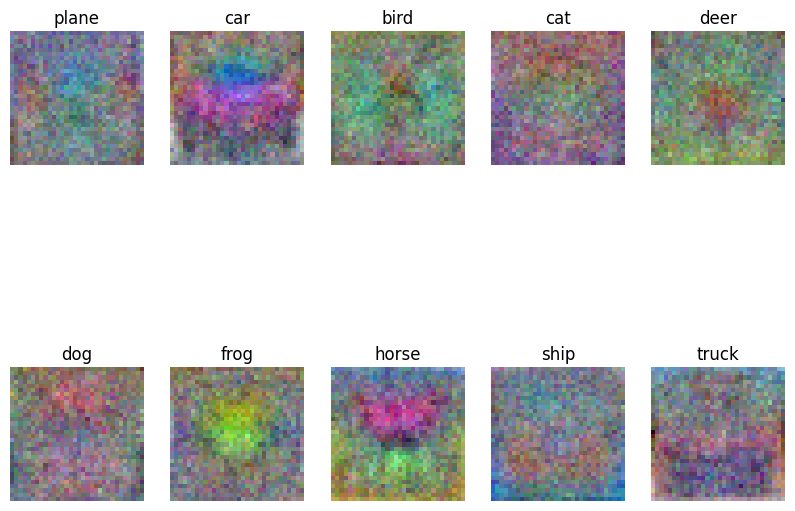

In [9]:
# Visualize the learned weights for each class
w = best_softmax.W[:-1,:] # strip out the bias
w = w.reshape(32, 32, 3, 10)

w_min, w_max = np.min(w), np.max(w)

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(10):
    plt.subplot(2, 5, i + 1)
    
    # Rescale the weights to be between 0 and 255
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])

- Reponse: I don't believe a response is needed here but  I found it interesting how much more smooth the softmax classifier made things. Intuitively this makes sense because it puts stricter bounds on things to make sure they fit the margin.